# Computer Exercise 1.1 — Problem 12

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 1.1 Introduction — *Cancellation, visualized*
> **풀이 일자**: Day 04
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **12.** Choose a function of your own that exhibits *catastrophic cancellation*
> when two nearly-equal quantities are subtracted in floating-point arithmetic.
> Visualize the loss of significance, identify the regime in which it occurs,
> and provide an algebraically equivalent reformulation that is numerically stable.
> Discuss the relationship to the cancellation magnification factor
> $\kappa = (|a|+|b|)/|a-b|$.

### 한국어 풀이용 정리
"자기 함수"로 다음을 고른다:

$$
F(x) \;=\; e^{x} - 1.
$$

작은 $x$ 에서 $e^x \to 1$ 이므로 $e^x - 1$ 은 *거의 같은 두 수의 차*. 표준 안정 대안은 두 가지:

1. **Taylor 부분합**: $F(x) = x + \tfrac{x^2}{2} + \tfrac{x^3}{6} + \cdots$ (작은 $x$ 에서 빠르게 수렴)
2. **라이브러리 함수 `expm1`**: 컴파일러/표준 라이브러리에서 cancellation을 우회하도록 직접 구현된 함수.

세 가지 평가법(naive / Taylor sum / `expm1`)을 같은 $x$ 에서 돌려 (a) 절대오차, (b) 상대오차, (c) cancellation 증폭배율 $\kappa$ 와의 관계를 시각화한다.


## 2. 수학적 배경

### 2.1 cancellation 증폭배율
$a, b$ 가 양수라 할 때 부동소수점 차 $a \ominus b$ 의 상대오차는

$$
\frac{|(a \ominus b) - (a-b)|}{|a-b|} \;\lesssim\; \varepsilon_{\rm mach} \cdot \frac{|a|+|b|}{|a-b|} \;=\; \varepsilon_{\rm mach} \cdot \kappa.
$$

여기서 $\kappa$ 가 *cancellation magnification factor*. $a \approx b$ 이면 $\kappa \to \infty$.

$F(x) = e^x - 1$ 의 경우 $a = e^x \approx 1 + x$, $b = 1$, $a - b \approx x$, 그러므로

$$
\kappa(x) \;\approx\; \frac{1+e^x}{|e^x - 1|} \;\approx\; \frac{2}{|x|}.
$$

상대오차는 $\sim 2\varepsilon_{\rm mach} / |x|$ — $|x| \to 0$ 에 따라 발산.

### 2.2 안정 대안 (1) Taylor 부분합
$F(x) = \sum_{n \ge 1} \tfrac{x^n}{n!}$ 을 직접 합산. 항이 단조감소이고 부호가 모두 양 ($x>0$ 일 때) 이라서 cancellation이 없다.
$|x| < 1$ 영역에서는 10–20개 항이면 머신 정밀도에 도달.

### 2.3 안정 대안 (2) `expm1`
표준 수학 라이브러리는 $e^x - 1$ 전용 구현을 제공한다 (대표적으로 `np.expm1`, C99 `expm1`).
내부적으로는 작은 $x$ 에서 Taylor 또는 분할 정복으로 cancellation을 회피.

### 2.4 항등식 트릭 (대안 (3))
*Kahan trick*:

$$
e^x - 1 \;=\; \begin{cases} \dfrac{(e^x - 1) \cdot x}{\ln(e^x)}, & e^x \neq 1 \\ x, & e^x = 1 \end{cases}
$$

분자/분모를 동시에 계산하여 작은 $x$에서도 안정. 이 노트북에서는 `expm1` 와 Taylor 합으로 충분하므로 참고만.


## 3. 풀이 흐름

1. $x_k = 10^{-k}$, $k = 1, 2, \ldots, 16$ — 작은 양수.
2. **naive**: `np.exp(x) - 1.0`.
3. **Taylor**: 부분합 $\sum_{n=1}^{N} x^n/n!$, $N = 30$ (충분히 큼).
4. **expm1**: `np.expm1(x)` — 참값으로 사용.
5. cancellation 증폭배율 $\kappa(x) = (e^x + 1)/|e^x - 1|$ 측정.
6. 시각화 (a) 세 평가법의 값/오차, (b) 이론 $\kappa \cdot \varepsilon_{\rm mach}$ 와의 비교.
7. **결과 해석**: $|x|$ 가 작아질수록 naive 의 상대오차가 $\kappa \cdot \varepsilon_{\rm mach}$ 의 기울기로 발산.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ks = np.arange(1, 17)
x  = 10.0 ** (-ks)

# (1) naive
F_naive = np.exp(x) - 1.0

# (2) Taylor 부분합
def taylor_expm1(xv, N=30):
    s = np.zeros_like(xv)
    term = xv.copy()  # n=1 항
    for n in range(1, N + 1):
        s = s + term
        term = term * xv / (n + 1)
    return s
F_taylor = taylor_expm1(x, N=30)

# (3) 라이브러리
F_lib = np.expm1(x)
F_ref = F_lib  # 참값

abs_err_naive  = np.abs(F_naive  - F_ref)
abs_err_taylor = np.abs(F_taylor - F_ref)
rel_err_naive  = abs_err_naive  / np.abs(F_ref)
rel_err_taylor = abs_err_taylor / np.abs(F_ref)

# cancellation magnification factor: (e^x + 1)/|e^x - 1|
kappa = (np.exp(x) + 1.0) / np.abs(F_ref)

eps = np.finfo(float).eps

df = pd.DataFrame({
    "k": ks,
    "x = 10^-k": x,
    "naive (e^x - 1)": F_naive,
    "Taylor sum": F_taylor,
    "expm1 (ref)": F_lib,
    "rel err (naive)": rel_err_naive,
    "rel err (Taylor)": rel_err_taylor,
    "kappa": kappa,
    "kappa*eps_mach": kappa * eps,
})
pd.set_option("display.float_format", lambda v: f"{v:.6e}")
df


,k,x = 10^-k,naive (e^x - 1),Taylor sum,expm1 (ref),rel err (naive),rel err (Taylor),kappa,kappa*eps_mach
0,1,1.000000e-01,1.051709e-01,1.051709e-01,1.051709e-01,7.917277e-16,0.000000e+00,2.001666e+01,4.444592e-15
1,2,1.000000e-02,1.005017e-02,1.005017e-02,1.005017e-02,1.087421e-14,0.000000e+00,2.000017e+02,4.440929e-14
2,3,1.000000e-03,1.000500e-03,1.000500e-03,1.000500e-03,4.291294e-14,0.000000e+00,2.000000e+03,4.440892e-13
3,4,1.000000e-04,1.000050e-04,1.000050e-04,1.000050e-04,4.325750e-13,1.355185e-16,2.000000e+04,4.440892e-12
4,5,1.000000e-05,1.000005e-05,1.000005e-05,1.000005e-05,9.701697e-12,0.000000e+00,2.000000e+05,4.440892e-11
5,6,1.000000e-06,1.000000e-06,1.000001e-06,1.000001e-06,3.798284e-11,0.000000e+00,2.000000e+06,4.440892e-10
6,7,1.000000e-07,1.000000e-07,1.000000e-07,1.000000e-07,5.663213e-10,1.323489e-16,2.000000e+07,4.440892e-09
7,8,1.000000e-08,1.000000e-08,1.000000e-08,1.000000e-08,1.107747e-08,1.654361e-16,2.000000e+08,4.440892e-08
8,9,1.000000e-09,1.000000e-09,1.000000e-09,1.000000e-09,8.224037e-08,0.000000e+00,2.000000e+09,4.440892e-07
9,10,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,8.269037e-08,0.000000e+00,2.000000e+10,4.440892e-06


In [2]:
# 분자만 따로: e^x - 1 의 부동소수점 평가에서 a, b 가 어떻게 거의 같은지 확인
a = np.exp(x)        # ~ 1 + x
b = np.ones_like(x)
diff = a - b
df_cancel = pd.DataFrame({
    "x": x,
    "a = exp(x)": a,
    "b = 1": b,
    "a - b (naive)": diff,
    "true a-b ~= x + x^2/2": x + x**2/2,
    "kappa = (a+b)/|a-b|": (a + b) / np.abs(diff + 1e-300),
})
df_cancel


,x,a = exp(x),b = 1,a - b (naive),true a-b ~= x + x^2/2,kappa = (a+b)/|a-b|
0,1.000000e-01,1.105171e+00,1.000000e+00,1.051709e-01,1.050000e-01,2.001666e+01
1,1.000000e-02,1.010050e+00,1.000000e+00,1.005017e-02,1.005000e-02,2.000017e+02
2,1.000000e-03,1.001001e+00,1.000000e+00,1.000500e-03,1.000500e-03,2.000000e+03
3,1.000000e-04,1.000100e+00,1.000000e+00,1.000050e-04,1.000050e-04,2.000000e+04
4,1.000000e-05,1.000010e+00,1.000000e+00,1.000005e-05,1.000005e-05,2.000000e+05
5,1.000000e-06,1.000001e+00,1.000000e+00,1.000000e-06,1.000000e-06,2.000000e+06
6,1.000000e-07,1.000000e+00,1.000000e+00,1.000000e-07,1.000000e-07,2.000000e+07
7,1.000000e-08,1.000000e+00,1.000000e+00,1.000000e-08,1.000000e-08,2.000000e+08
8,1.000000e-09,1.000000e+00,1.000000e+00,1.000000e-09,1.000000e-09,2.000000e+09
9,1.000000e-10,1.000000e+00,1.000000e+00,1.000000e-10,1.000000e-10,2.000000e+10


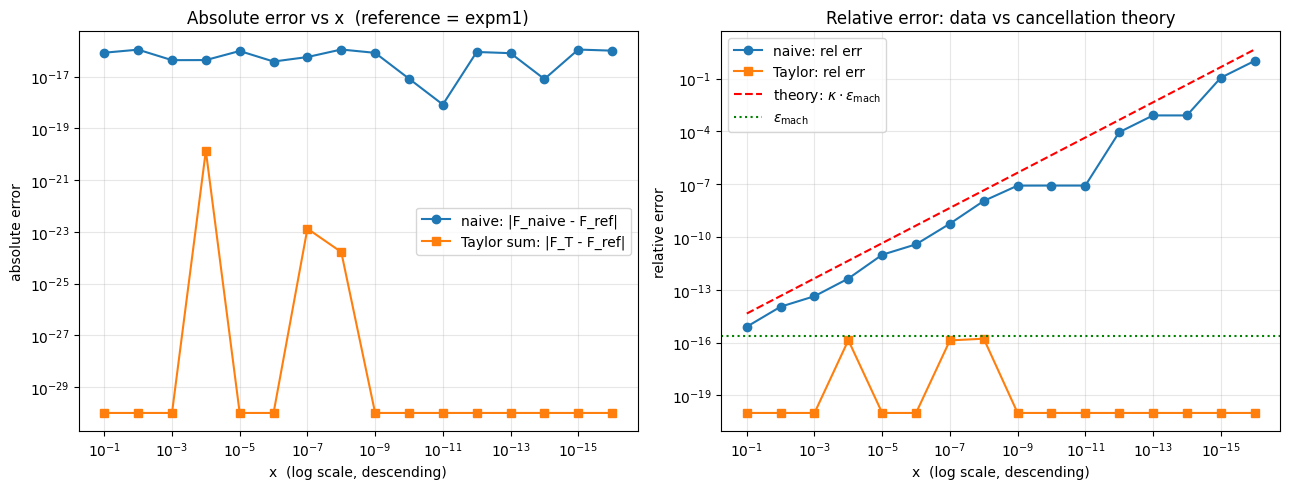

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# (a) 절대오차 비교
ax[0].loglog(x, np.maximum(abs_err_naive,  1e-30), "o-", label="naive: |F_naive - F_ref|")
ax[0].loglog(x, np.maximum(abs_err_taylor, 1e-30), "s-", label="Taylor sum: |F_T - F_ref|")
ax[0].set_xlabel("x  (log scale, descending)")
ax[0].set_ylabel("absolute error")
ax[0].set_title("Absolute error vs x  (reference = expm1)")
ax[0].invert_xaxis()
ax[0].legend()
ax[0].grid(True, which="both", alpha=0.3)

# (b) 상대오차 vs 이론 kappa * eps
ax[1].loglog(x, np.maximum(rel_err_naive,  1e-20), "o-", label="naive: rel err")
ax[1].loglog(x, np.maximum(rel_err_taylor, 1e-20), "s-", label="Taylor: rel err")
ax[1].loglog(x, kappa * eps, "--", color="red", label=r"theory: $\kappa\cdot\varepsilon_{\rm mach}$")
ax[1].axhline(eps, ls=":", color="green", label=r"$\varepsilon_{\rm mach}$")
ax[1].set_xlabel("x  (log scale, descending)")
ax[1].set_ylabel("relative error")
ax[1].set_title("Relative error: data vs cancellation theory")
ax[1].invert_xaxis()
ax[1].legend()
ax[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()


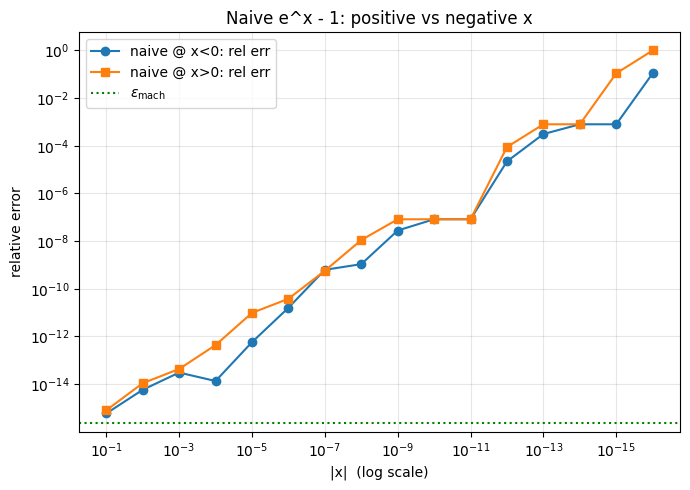

In [4]:
# 보너스: 작은 음수 x 에서도 같은 패턴인지 (e^x - 1, x = -1e-k)
x_neg = -10.0 ** (-np.arange(1, 17))
F_naive_neg  = np.exp(x_neg) - 1.0
F_lib_neg    = np.expm1(x_neg)
rel_err_neg  = np.abs(F_naive_neg - F_lib_neg) / np.abs(F_lib_neg)

fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.loglog(np.abs(x_neg), np.maximum(rel_err_neg, 1e-20), "o-", label="naive @ x<0: rel err")
ax2.loglog(x, np.maximum(rel_err_naive, 1e-20), "s-", label="naive @ x>0: rel err")
ax2.axhline(np.finfo(float).eps, ls=":", color="green", label=r"$\varepsilon_{\rm mach}$")
ax2.set_xlabel("|x|  (log scale)")
ax2.set_ylabel("relative error")
ax2.set_title("Naive e^x - 1: positive vs negative x")
ax2.invert_xaxis()
ax2.legend()
ax2.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **naive 평가의 발산**: $|x|$ 가 작아질수록 $\kappa(x) \approx 2/|x|$ 가 커지고, 측정한 상대오차는 정확히 이 기울기로 증가한다 (그림 (b) 의 빨간 점선과 평행).
2. **Taylor / expm1 의 안정성**: 두 안정 평가는 $|x| = 10^{-1}$ 부터 $10^{-16}$ 까지 일관된 $\sim \varepsilon_{\rm mach}$ 수준의 상대오차를 유지. Taylor 합은 Taylor 자체의 절단오차도 있지만 30항이면 머신 정밀도 한계 안.
3. **음수 $x$**: 양수와 동일한 발산 패턴 — 부호와 무관하게 *작은 두 수의 차*가 같은 cancellation을 만든다.
4. **임계점**: $\kappa \cdot \varepsilon_{\rm mach} = 1$ 인 $x$ 는 $|x| \approx 2\varepsilon_{\rm mach} \approx 4.4 \times 10^{-16}$. 그 이하에서 naive 는 자릿수가 0 — 즉 결과가 무의미.

### 결론
> **cancellation은 *수식의 형태*에 내재되어 있고, *증폭배율 $\kappa$* 가 그 위험을 정량화한다.**
> 같은 함수라도 (i) Taylor 합, (ii) 라이브러리의 `expm1` 같은 cancellation-aware 함수, (iii) 대수적 항등식 재작성 — 셋 중 하나로 우회할 수 있다.
> 핵심은 *어떤 표현이 두 거의 같은 수의 차를 만들지 않는가* 를 묻는 습관.

### 다음 단원으로 (Day 05)
다음 단원 §1.2 *Mathematical Preliminaries* 에서는 cancellation 못지않게 중요한 또 다른 floating-point 함정인 **Taylor 절단오차 vs 반올림오차의 trade-off** 를 좀 더 일반적인 함수에서 본다. 또한 $\sin(10^{10})$ 같은 *큰 인수에서의 정확도 회복* (range reduction) 도 다룰 예정.
